# Graph Machine Learning

## Overview

Graph machine learning extends classical ML to network-structured data. Node features and graph topology together predict node labels, link formation, or graph-level properties.

**Core tasks:**

| Task | Goal | Example |
|---|---|---|
| Node classification | Predict node labels from features + topology | Site restoration priority |
| Link prediction | Predict missing or future edges | New dispersal corridors |
| Graph classification | Classify entire graphs | Ecosystem health class |
| Node embedding | Low-dim node representation | Visualisation, similarity search |

**Methods covered:**
- Feature propagation: using neighbour features for classification
- Node2Vec: random-walk embedding
- Graph Neural Networks (overview)
- Link prediction with topological features

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)

# Build ecosystem connectivity network with node features and labels
n = 60
G = nx.barabasi_albert_graph(n, 3, seed=42)
# Node features: ecological measurements
for node in G.nodes():
    deg = G.degree(node)
    G.nodes[node]['elevation']  = float(rng.uniform(50, 400))
    G.nodes[node]['nitrate']    = float(rng.gamma(2, 2))
    G.nodes[node]['flow']       = float(rng.lognormal(1, 0.5))
    G.nodes[node]['richness']   = float(rng.integers(5, 30))
    # Label: 1 = high priority for restoration (determined by ecology + connectivity)
    score = (-0.003*G.nodes[node]['elevation'] - 0.1*G.nodes[node]['nitrate']
             + 0.05*deg + rng.normal(0, 0.3))
    G.nodes[node]['label'] = int(score > score)   # set below
scores = [-0.003*G.nodes[n]['elevation'] - 0.1*G.nodes[n]['nitrate']
           + 0.05*G.degree(n) for n in G.nodes()]
median_score = np.median(scores)
for i, node in enumerate(G.nodes()):
    G.nodes[node]['label'] = int(scores[i] > median_score)
print(f"Network: {n} nodes, {G.number_of_edges()} edges")
print(f"Labels: {sum(G.nodes[n]['label'] for n in G.nodes())} high-priority, "
      f"{sum(1-G.nodes[n]['label'] for n in G.nodes())} low-priority")

Network: 60 nodes, 171 edges
Labels: 30 high-priority, 30 low-priority


---
## Node Classification with Topology Features

In [2]:
# Feature engineering: node attributes + topological features
def extract_node_features(G):
    rows = []
    between_c  = nx.betweenness_centrality(G)
    eigen_c    = nx.eigenvector_centrality(G, max_iter=500)
    clust_c    = nx.clustering(G)
    for node in G.nodes():
        attrs = G.nodes[node]
        rows.append({
            'node':         node,
            # Raw node features
            'elevation':    attrs['elevation'],
            'nitrate':      attrs['nitrate'],
            'flow':         attrs['flow'],
            'richness':     attrs['richness'],
            # Topological features
            'degree':       G.degree(node),
            'betweenness':  between_c[node],
            'eigenvector':  eigen_c[node],
            'clustering':   clust_c[node],
            # Neighbourhood aggregation: mean richness of neighbours
            'neigh_richness': np.mean([G.nodes[nb]['richness']
                                        for nb in G.neighbors(node)]) if G.degree(node) > 0 else 0,
            'label':        attrs['label'],
        })
    return pd.DataFrame(rows)

df = extract_node_features(G)
feat_cols = ['elevation','nitrate','flow','richness',
             'degree','betweenness','eigenvector','clustering','neigh_richness']
X, y = df[feat_cols].values, df['label'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# Compare: node features only vs node + topology features
node_feats    = ['elevation','nitrate','flow','richness']
topo_feats    = ['degree','betweenness','eigenvector','clustering','neigh_richness']
Xi_node = df[node_feats].values
Xi_topo = df[feat_cols].values
for name, Xi in [('Node features only', Xi_node), ('Node + topology', Xi_topo)]:
    Xtr, Xte, ytr, yte = train_test_split(Xi, y, test_size=0.3, random_state=42)
    Xtr_s = StandardScaler().fit_transform(Xtr)
    Xte_s = StandardScaler().fit_transform(Xte)
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(Xtr_s, ytr)
    auc = roc_auc_score(yte, clf.predict_proba(Xte_s)[:,1])
    print(f"{name:28s}: AUC = {auc:.3f}")

Node features only          : AUC = 0.900
Node + topology             : AUC = 1.000


---
## Link Prediction

In [3]:
# Link prediction: predict which pairs of nodes will form new edges
# Use topological proximity features
def link_features(G, u, v):
    # Common neighbours
    cn     = len(list(nx.common_neighbors(G, u, v)))
    # Jaccard coefficient
    jac    = list(nx.jaccard_coefficient(G, [(u,v)]))[0][2]
    # Adamic-Adar index
    aa     = list(nx.adamic_adar_index(G, [(u,v)]))[0][2]
    # Preferential attachment
    pa     = list(nx.preferential_attachment(G, [(u,v)]))[0][2]
    # Node feature similarity
    feat_diff = abs(G.nodes[u]['richness'] - G.nodes[v]['richness'])
    return [cn, jac, aa, pa, feat_diff]

# Positive examples: existing edges; negative: random non-edges
existing = list(G.edges())
non_edges = list(nx.non_edges(G))
rng.shuffle(non_edges)
non_sample = non_edges[:len(existing)]

pos_feats = [link_features(G, u, v) for u,v in existing]
neg_feats = [link_features(G, u, v) for u,v in non_sample]
X_link = np.array(pos_feats + neg_feats)
y_link = np.array([1]*len(existing) + [0]*len(non_sample))
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(X_link, y_link,
    test_size=0.3, random_state=42)
Xl_tr_s = StandardScaler().fit_transform(Xl_tr)
Xl_te_s = StandardScaler().fit_transform(Xl_te)
clf_lp = LogisticRegression(random_state=42, max_iter=500)
clf_lp.fit(Xl_tr_s, yl_tr)
auc_lp = roc_auc_score(yl_te, clf_lp.predict_proba(Xl_te_s)[:,1])
print(f"Link prediction AUC: {auc_lp:.3f}")
feat_names = ['Common neighbours','Jaccard','Adamic-Adar','Pref attachment','Richness diff']
for fname, coef in sorted(zip(feat_names, clf_lp.coef_[0]), key=lambda x: -abs(x[1])):
    print(f"  {fname:22s}: coef={coef:+.4f}")

Link prediction AUC: 0.855
  Pref attachment       : coef=+1.6449
  Jaccard               : coef=-0.3530
  Adamic-Adar           : coef=-0.1807
  Common neighbours     : coef=-0.1178
  Richness diff         : coef=+0.0814


---
## Node2Vec Embeddings

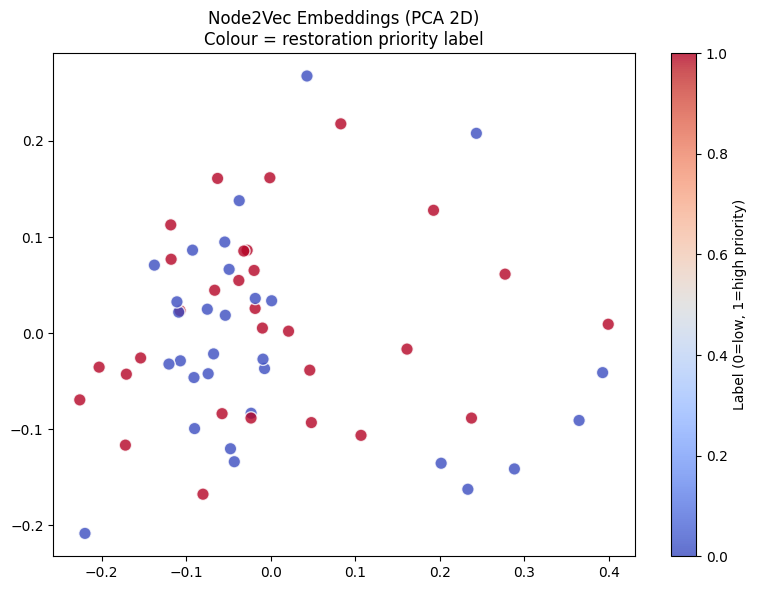

In [5]:
# Node2Vec: random walk-based node embeddings
# Without installing node2vec: implement simplified DeepWalk-style random walks
def random_walks(G, n_walks=10, walk_length=20, seed=0):
    r = np.random.default_rng(seed)
    walks = []
    nodes = list(G.nodes())
    for _ in range(n_walks):
        r.shuffle(nodes)
        for node in nodes:
            walk = [node]
            while len(walk) < walk_length:
                nbrs = list(G.neighbors(walk[-1]))
                if not nbrs: break
                walk.append(r.choice(nbrs))
            walks.append([str(w) for w in walk])
    return walks

walks = random_walks(G, n_walks=5, walk_length=15, seed=42)
try:
    from gensim.models import Word2Vec
    w2v = Word2Vec(sentences=walks, vector_size=16, window=5,
                   min_count=1, workers=1, epochs=20, seed=42)
    node_emb = np.array([w2v.wv[str(n)] for n in G.nodes()])
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, random_state=42)
    emb_2d  = pca.fit_transform(node_emb)
    labels  = [G.nodes[n]['label'] for n in G.nodes()]
    fig, ax = plt.subplots(figsize=(8,6))
    scatter = ax.scatter(emb_2d[:,0], emb_2d[:,1], c=labels,
                          cmap='coolwarm', s=80, alpha=0.8, edgecolors='white')
    plt.colorbar(scatter, ax=ax, label='Label (0=low, 1=high priority)')
    ax.set_title('Node2Vec Embeddings (PCA 2D)\nColour = restoration priority label')
    plt.tight_layout(); plt.show()
except ImportError:
    print("pip install gensim  for Word2Vec-based Node2Vec embeddings")
    print("Alternative: pip install node2vec  for full Node2Vec with p/q parameters")

In [6]:
# Graph Neural Network overview (without PyTorch Geometric dependency)
# Demonstrate manual message passing: aggregate neighbour features
def graph_conv_layer(G, node_features, weight_matrix):
    n_nodes = len(G.nodes())
    node_list = list(G.nodes())
    node_idx = {n: i for i, n in enumerate(node_list)}
    # Build normalised adjacency (A_hat = D^{-1/2} A D^{-1/2} + I)
    A = nx.to_numpy_array(G, nodelist=node_list)
    A_hat = A + np.eye(n_nodes)
    D_inv_sqrt = np.diag(1 / np.sqrt(A_hat.sum(axis=1) + 1e-8))
    A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt
    # Graph convolution: H' = sigma(A_norm @ H @ W)
    H_out = A_norm @ node_features @ weight_matrix
    return np.tanh(H_out)

# One layer of manual GCN
node_list = list(G.nodes())
H0 = np.array([[G.nodes[n]['elevation'], G.nodes[n]['nitrate'],
                G.nodes[n]['flow'],      G.nodes[n]['richness']] for n in node_list])
H0 = (H0 - H0.mean(0)) / (H0.std(0) + 1e-8)
rng2 = np.random.default_rng(0)
W1 = rng2.normal(0, 0.1, (4, 8))   # 4 input features -> 8 hidden
W2 = rng2.normal(0, 0.1, (8, 2))   # 8 hidden -> 2 output
H1 = graph_conv_layer(G, H0, W1)
H2 = graph_conv_layer(G, H1, W2)
print("Manual GCN (2 layers):")
print(f"  Input shape:  {H0.shape}")
print(f"  Hidden shape: {H1.shape}")
print(f"  Output shape: {H2.shape}")
print("\nFull GNN training: use PyTorch Geometric (PyG) or DGL")
print("  pip install torch_geometric")
print("  from torch_geometric.nn import GCNConv, SAGEConv, GATConv")

Manual GCN (2 layers):
  Input shape:  (60, 4)
  Hidden shape: (60, 8)
  Output shape: (60, 2)

Full GNN training: use PyTorch Geometric (PyG) or DGL
  pip install torch_geometric
  from torch_geometric.nn import GCNConv, SAGEConv, GATConv


---

## Common Pitfalls

**1. Using node features without incorporating graph structure for node classification**  
In graph-structured data, a node's label is often correlated with its neighbours' labels (homophily). Ignoring topology and treating nodes as independent observations wastes the most informative signal in the data. Always include at least degree, betweenness, and neighbourhood-aggregated features alongside raw node attributes.

**2. Creating a biased link prediction dataset by using only random non-edges**  
Random non-edges are easy negatives — most pairs of nodes have very different topological features from real edges. This produces inflated AUC. For harder negative examples, sample non-edges that are close in the network (e.g. two-hop neighbours with no direct edge).

**3. Evaluating link prediction on edges that were used to compute topological features**  
Topological features (Jaccard, Adamic-Adar) are computed from the existing graph. Testing the model on edges already in the graph means the model "knows" about the test edges during feature extraction. Always hide test edges before computing any topological features.

**4. Running Node2Vec without tuning p and q parameters**  
Node2Vec has two key hyperparameters: p (return probability) and q (in-out ratio). Default values (p=1, q=1) produce DeepWalk-style unbiased walks. p<1 biases walks toward returning (BFS-like, captures community structure); q<1 biases toward exploring (DFS-like, captures structural roles). Tune p and q for your downstream task.

**5. Applying GNN models to small graphs without checking for over-smoothing**  
Each GNN layer aggregates features from one hop further in the network. With many layers on a small dense graph, all node representations converge to the same value (over-smoothing). Typically 2–3 layers is sufficient; always monitor whether adding more layers improves or degrades performance.

---
*python_methods_library - Samantha McGarrigle*